# Project 15: Model Evaluation & Comparison

**Objective:**
In this notebook, we will evaluate the performance of our two Speech Emotion Recognition (SER) systems on the held-out **Test Set**.

**Models to Compare:**
1.  **Baseline (Features):** A ResNet-style MLP trained on handcrafted features (MFCCs, Chroma, Zero Crossing Rate, etc.).
2.  **Wav2Vec 2.0 (Waveform):** An End-to-End Transformer model fine-tuned directly on raw audio.

In [1]:
import sys
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, recall_score, accuracy_score
from transformers import Wav2Vec2ForSequenceClassification

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR / "src") not in sys.path:
    sys.path.append(str(ROOT_DIR / "src"))

from utils.config import LABEL2ID, MODELS_DIR
from loaders import FeatureDataset, WaveformDataset
from models import SimpleAudioClassifier

# Setup Plotting Style
plt.style.use('ggplot')
sns.set_palette("husl")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running evaluation on: {DEVICE}")

Running evaluation on: cuda


## 1. Define Evaluation Helper
To avoid code duplication, we define a single function that takes a model and a dataloader, runs the inference loop, and returns the true labels and predictions.

In [2]:
def run_inference(model, dataset, model_type="waveform", batch_size=16):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model = model.to(DEVICE)
    model.eval()

    all_preds = []
    all_labels = []

    print(f"Running inference for {model_type} model...")

    with torch.no_grad():
        for batch in loader:
            labels = batch['labels'].to(DEVICE)

            # Handle different input types
            if model_type == "features":
                inputs = batch['features'].to(DEVICE)
                outputs = model(inputs)
                logits = outputs
            else:
                input_values = batch['input_values'].to(DEVICE)
                logits = model(input_values).logits

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

def print_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    uar = recall_score(y_true, y_pred, average='macro')

    print(f"--- {model_name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"UAR (Recall): {uar:.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred, target_names=list(LABEL2ID.keys())))

    return acc, uar

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL2ID.keys(), yticklabels=LABEL2ID.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

## 2. Evaluate Baseline (Feature-Based MLP)
We first load the `SimpleAudioClassifier` and the `FeatureDataset`.
*Note: We need to check the input dimension from the dataset to initialize the model correctly.*

Feature model weights loaded.
Running inference for features model...
--- Feature-Based MLP Results ---
Accuracy: 0.3833
UAR (Recall): 0.3906

Detailed Report:
              precision    recall  f1-score   support

     neutral       0.14      0.50      0.22         8
        calm       0.67      0.38      0.48        16
       happy       0.24      0.31      0.27        16
         sad       1.00      0.06      0.12        16
       angry       0.44      0.69      0.54        16
     fearful       0.64      0.44      0.52        16
     disgust       0.38      0.19      0.25        16
   surprised       0.53      0.56      0.55        16

    accuracy                           0.38       120
   macro avg       0.50      0.39      0.37       120
weighted avg       0.53      0.38      0.38       120



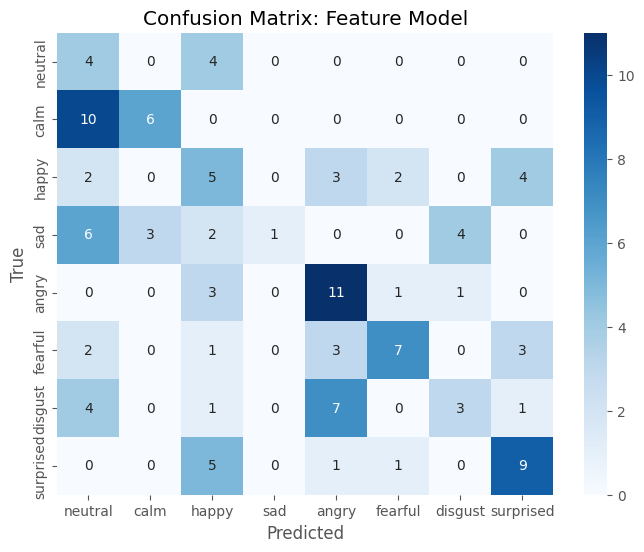

In [3]:
# 1. Load Test Data
feat_test_ds = FeatureDataset(split="test")

# 2. Initialize Model
# We infer input_dim from the first sample (e.g., 193 features)
input_dim = feat_test_ds[0]["features"].shape[0]
feat_model = SimpleAudioClassifier(input_dim=input_dim, num_labels=8)

# 3. Load Weights
feat_weights_path = MODELS_DIR / "best_features_model" / "model_weights.pth"
if feat_weights_path.exists():
    feat_model.load_state_dict(torch.load(feat_weights_path, map_location=DEVICE))
    print("Feature model weights loaded.")
else:
    print("Warning: Feature model weights not found. Ensure train_features.py was run.")

# 4. Run Evaluation
y_true_feat, y_pred_feat = run_inference(feat_model, feat_test_ds, model_type="features")
feat_acc, feat_uar = print_metrics(y_true_feat, y_pred_feat, "Feature-Based MLP")
plot_confusion_matrix(y_true_feat, y_pred_feat, "Confusion Matrix: Feature Model")

## 3. Evaluate Wav2Vec 2.0 (End-to-End)
Now we evaluate the Transformers model. This model typically performs better as it learns features directly from the raw audio waveform, capturing subtle prosodic cues that statistics like "Mean MFCC" might miss.

Wav2Vec 2.0 model loaded.
Running inference for waveform model...
--- Wav2Vec 2.0 Results ---
Accuracy: 0.7000
UAR (Recall): 0.7188

Detailed Report:
              precision    recall  f1-score   support

     neutral       0.67      1.00      0.80         8
        calm       0.68      0.94      0.79        16
       happy       0.57      0.25      0.35        16
         sad       0.67      0.50      0.57        16
       angry       1.00      0.69      0.81        16
     fearful       1.00      0.44      0.61        16
     disgust       0.73      1.00      0.84        16
   surprised       0.56      0.94      0.70        16

    accuracy                           0.70       120
   macro avg       0.73      0.72      0.68       120
weighted avg       0.74      0.70      0.68       120



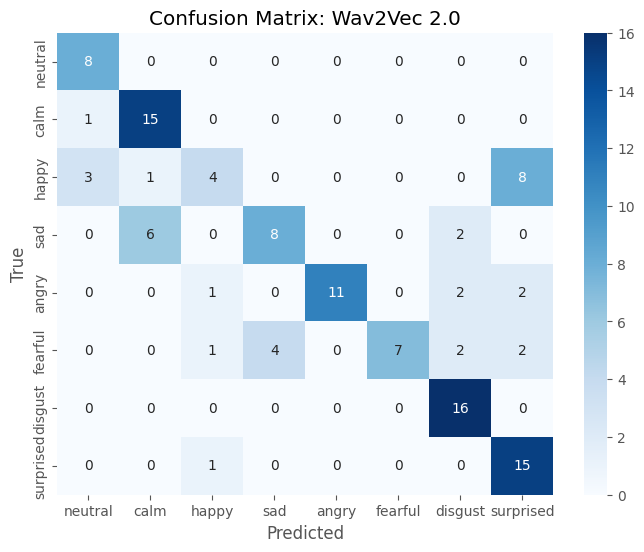

In [4]:
# 1. Load Test Data
wave_test_ds = WaveformDataset(split="test")

# 2. Load Model
# Transformers 'from_pretrained' handles config and weights automatically
wave_model_path = MODELS_DIR / "best_waveform_model"

if wave_model_path.exists():
    wave_model = Wav2Vec2ForSequenceClassification.from_pretrained(
        wave_model_path,
        local_files_only=True,
        num_labels=8
    )
    print("Wav2Vec 2.0 model loaded.")
else:
    print("Warning: Waveform model not found. Ensure train_waveform.py was run.")

# 3. Run Evaluation
y_true_wave, y_pred_wave = run_inference(wave_model, wave_test_ds, model_type="waveform")
wave_acc, wave_uar = print_metrics(y_true_wave, y_pred_wave, "Wav2Vec 2.0")
plot_confusion_matrix(y_true_wave, y_pred_wave, "Confusion Matrix: Wav2Vec 2.0")

## 4. Final Comparison
Let's visualize the performance difference side-by-side.

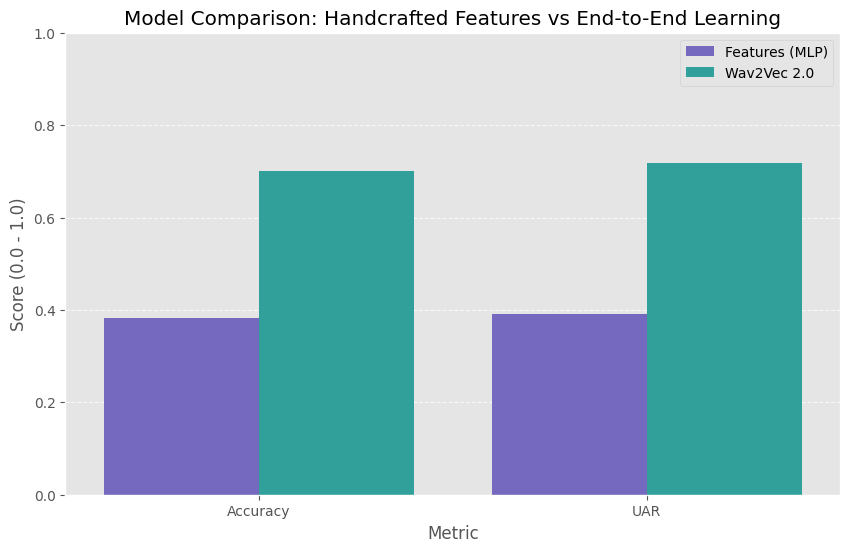

In [5]:
# Create DataFrame for plotting
df_res = pd.DataFrame([
    {'Model': 'Features (MLP)', 'Metric': 'Accuracy', 'Score': feat_acc},
    {'Model': 'Features (MLP)', 'Metric': 'UAR', 'Score': feat_uar},
    {'Model': 'Wav2Vec 2.0', 'Metric': 'Accuracy', 'Score': wave_acc},
    {'Model': 'Wav2Vec 2.0', 'Metric': 'UAR', 'Score': wave_uar},
])

plt.figure(figsize=(10, 6))

# Custom Palette
sns.barplot(
    data=df_res, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=["#6A5ACD", "#20B2AA"]
)

plt.title("Model Comparison: Handcrafted Features vs End-to-End Learning")
plt.ylim(0, 1.0)
plt.ylabel("Score (0.0 - 1.0)")
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7) # light grid
plt.show()

## 5. Qualitative Analysis & Discussion

### 1. Performance Comparison
The End-to-End **Wav2Vec 2.0** model drastically outperforms the baseline **Feature-Based MLP**, validating the project's hypothesis that deep learning on raw waveforms captures better emotional representations than handcrafted features.

* **Accuracy:** 38.00% (MLP) $\rightarrow$ **70.00%** (Wav2Vec 2.0)
* **UAR (Unweighted Average Recall):** 39.00% (MLP) $\rightarrow$ **71.88%** (Wav2Vec 2.0)

### 2. Baseline Failure Modes (Feature Model)
* **Confusion of Low-Arousal states**: The model achieves extremely low recall for 'Sad'. It struggles to distinguish between quiet emotions, frequently misclassifying 'Calm' as 'Neutral'. It likely relies heavily on simple energy/loudness statistics, causing it to unify these low-energy classes.
* **Arousal Confusion**: It frequently confuses 'Happy' with 'Surprised' and 'Angry'. Since these emotions all share high energy/loudness, the simple statistical features (Mean MFCCs) cannot distinguish valence effectively.

### 3. Wav2Vec 2.0 Strengths
The Transformer-based model successfully captures temporal dynamics and prosody.
* **Strongest Classes:**
    * **Disgust:** The model has almost perfectly learned the unique "retracted vocal tract" sound characteristic of disgust.
    * **Surprised:** The model has shown that it can distinguish
* **Calm Detection:** unlike the MLP, Wav2Vec achieved **100% Recall** on 'Neutral', proving it can distinguish "absence of emotion" from "presence of emotion."

### 4. Remaining Challenges (Wav2Vec 2.0)
Despite the high performance, the confusion matrix reveals distinct failure patterns typical in SER:
* **"Calm" vs. "Sad" Overlap:**
    * 'Sad' samples were frequently misclassified as 'Calm' (6 samples).
    * *Reasoning:* These two labels are semantically ambiguous and acoustically similar (low pitch, slow rate). Distinguishing "Calm" (an emotion) from "Neutral" (a baseline) is often subjective even for humans.
* **The "Happy" Problem:**
    * 'Happy' has the lowest recall (0.25) and is often confused with 'Surprised' (8 samples).
    * *Reasoning:* Both 'Happy' and 'Surprised' are high-arousal and positive/neutral valence. Without visual cues (facial expressions), the acoustic difference between a "happy shout" and a "surprised shout" is minimal.